Existem funções poderosas que são usada para infuênciar outras funções dentro .

Esse a execução desse tipo de coisa é chamado de 'Paradigma Funcional', veja mais sobre ela e os outros três tipos na aula:
[paradigmas_de_programacao](<../09-POO com Python/09-01-paradigmas_de_programacao.ipynb>)
Saber sobre isso o faz um programador de experiêcia avançada.

Existem três tipos de funções que são usadas justamente para o paradigma funcional:

# ***map()***

A função map() é uma das ferramentas mais poderosas do paradigma funcional no Python. Ela serve para aplicar uma determinada função a cada item de uma lista (ou qualquer outro iterável) de uma só vez, sem que você precise escrever um loop for manualmente.

Pense nela como uma linha de montagem: de um lado entram os dados brutos, no meio existe uma máquina (a função) que transforma esses dados, e do outro lado sai o produto transformado.


----------------------------------------------------------------------------------------------------

## 1. A Sintaxe do map()
A estrutura básica é:

    *map(funcao, iteravel)*

- funcao: A regra que você quer aplicar (pode ser uma função comum def, uma função lambda ou até funções nativas como int ou str).

- iteravel: A coleção de dados que você quer transformar (lista, tupla, etc.).

## 2. Exemplo Prático: Transformando Números

Imagine que você tem uma lista de preços e quer aplicar um aumento de 10% em todos eles.

O jeito tradicional (for):

In [1]:
precos = [100, 200, 300]
novos_precos = []
for p in precos:
    novos_precos.append(p * 1.1)

Com o map() e lambda:

In [2]:
precos = [100, 200, 300]
# Aplicamos a conta x * 1.1 para cada x em precos
novos_precos = map(lambda x: x * 1.1, precos)

# O map retorna um "objeto map" (preguiçoso), então precisamos converter para lista
print(list(novos_precos)) 
# Saída: [110.0, 220.0, 330.0]

[110.00000000000001, 220.00000000000003, 330.0]


----------------------------------------------------------------------------------------------------

## 3. O conceito de "Lazy Evaluation" (Execução Preguiçosa)
Um detalhe técnico importante: o map() não gera a nova lista imediatamente na memória. Ele cria um iterador.

- Ele só processa o próximo item quando você realmente pede por ele (como em um for ou ao converter para list()).

- Vantagem: Isso economiza muita memória se você estiver lidando com milhões de dados, pois o Python não precisa guardar o resultado de todos ao mesmo tempo.

----------------------------------------------------------------------------------------------------

## 4. Usando com Múltiplas Listas
O map() é inteligente: se a sua função aceita dois argumentos, você pode passar duas listas para ele!

In [3]:
def somar(a, b):
    return a + b

lista1 = [1, 2, 3]
lista2 = [10, 20, 30]

resultado = map(somar, lista1, lista2)
print(list(resultado)) # Saída: [11, 22, 33]

[11, 22, 33]


----------------------------------------------------------------------------------------------------

## 5. map() vs List Comprehension
Você deve ter notado que o map() faz algo muito parecido com a List Comprehension que vimos antes. Qual a diferença?

![map()_vs_comprehension.png](attachment:map()_vs_comprehension.png)
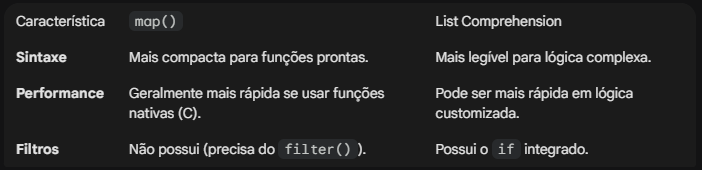

----------------------------------------------------------------------------------------------------

## Resumo: Quando usar map()?

- Use quando você já tem uma função pronta (como int, str, ou uma função de uma biblioteca) e quer aplicá-la em toda uma lista.

- Use quando estiver lidando com grandes volumes de dados e quiser aproveitar a "preguiça" (economia de memória) do iterador.

----------------------------------------------------------------------------------------------------

# ***filter()***

Se o map() é a transformação, o filter() é a seleção. Enquanto o primeiro altera cada item da lista, o segundo decide quem "sobrevive" e quem é descartado.

Ambas são funções do paradigma funcional e funcionam de forma muito parecida, mas com objetivos opostos.


----------------------------------------------------------------------------------------------------

## 1. A Lógica do filter()
A sintaxe é idêntica à do map:

     filter(funcao, iteravel)

A grande diferença é que a função que você passa para o filter deve obrigatoriamente retornar um Booleano (True ou False).

- Se a função retornar True, o item fica na lista.

- Se retornar False, o item é jogado fora.

## 2. Exemplo Prático: Filtrando Números
Imagine que você tem uma lista de idades e quer apenas as que são maiores de 18 anos.

In [4]:
idades = [12, 25, 8, 18, 40, 15, 32]

# A função lambda retorna True se for >= 18
maiores = filter(lambda idade: idade >= 18, idades)

print(list(maiores)) 
# Saída: [25, 18, 40, 32]

[25, 18, 40, 32]


Note que os números não mudaram (como aconteceria no map), eles apenas foram filtrados.

## 3. Usando filter() com Strings
Isso é muito útil para limpar dados, como remover nomes vazios de uma lista:

In [5]:
usuarios = ["Alice", "", "Bruno", " ", "Carla", None]

# O Python considera strings vazias e None como False. 
# Se passarmos None como função, o filter remove tudo que for "Falsy"
usuarios_limpos = filter(None, usuarios)

print(list(usuarios_limpos)) 
# Saída: ['Alice', 'Bruno', ' ', 'Carla'] 
# (Note que o espaço vazio " " ficou, pois não é uma string vazia!)

['Alice', 'Bruno', ' ', 'Carla']


## 4. A Dupla Dinâmica: map() + filter()
É muito comum usar os dois juntos. Imagine que você quer:

1. Pegar uma lista de números.

2. Filtrar apenas os pares.

3. Dobrar o valor dos que sobraram.

In [6]:
numeros = [1, 2, 3, 4, 5, 6]

# 1. Filtra os pares
pares = filter(lambda x: x % 2 == 0, numeros)

# 2. Dobra os pares
dobro_dos_pares = map(lambda x: x * 2, pares)

print(list(dobro_dos_pares)) 
# Saída: [4, 8, 12]

[4, 8, 12]


## 5. filter() vs List Comprehension
Assim como o map, o filter também pode ser substituído por uma List Comprehension, que geralmente é considerada mais legível em Python:

In [ ]:
# Com filter:
res = list(filter(lambda x: x > 10, lista))

# Com List Comprehension:
res = [x for x in lista if x > 10]

## Resumo:
- map(): Transforma todos os itens (Entra X, sai Y).

- filter(): Filtra os itens (Entra X, sai X ou nada).

- reduce(): Reduz a lista a um único valor (Soma de tudo, por exemplo). Nota: O reduce não é mais uma função nativa, ele fica no módulo functools.

----------------------------------------------------------------------------------------------------

# ***reduce()***

O reduce() é o "finalizador" do trio. Enquanto o map e o filter sempre devolvem uma nova lista (ou iterador), o reduce pega uma lista inteira e a condensa em um único valor final.

Diferente dos outros dois, ele não vem "solto" no Python; você precisa buscá-lo no módulo functools.


## 1. Como o reduce() pensa?
Ele funciona de forma cumulativa. Ele aplica uma função aos dois primeiros itens, pega o resultado, aplica ao terceiro, pega esse novo resultado, aplica ao quarto, e assim por diante.

Imagine que você está somando uma pilha de moedas:

1. Pega duas moedas e soma.

2. Pega o resultado e soma com a próxima moeda da pilha.

3. Repete até sobrar apenas um valor total na mão.

## 2. Exemplo Prático: Multiplicando todos os itens
Se você quiser saber o produto (multiplicação) de todos os números de uma lista:

In [8]:
from functools import reduce

numeros = [1, 2, 3, 4, 5]

# A função lambda recebe dois argumentos: 
# 'a' (o acumulador/resultado parcial) e 'b' (o próximo item da lista)
resultado = reduce(lambda a, b: a * b, numeros)

print(resultado) 
# Passo a passo:
# 1 * 2 = 2
# 2 * 3 = 6
# 6 * 4 = 24
# 24 * 5 = 120 (Resultado final!)

120


## 3. O Argumento Opcional: Valor Inicial
O reduce aceita um terceiro argumento que serve como o "ponto de partida" do acumulador.

In [9]:
# Começando a soma já com 100 reais no bolso
lista = [10, 20, 30]
total = reduce(lambda a, b: a + b, lista, 100)

print(total) # Saída: 160 (100 + 10 + 20 + 30)

160


## 4. O "Trio super poderoso" no Python
Agora você conhece o fluxo completo do processamento de dados funcional:

1. filter: Limpa o que você não quer.

2. map: Transforma o que sobrou.

3. reduce: Consolida tudo em um resultado final.

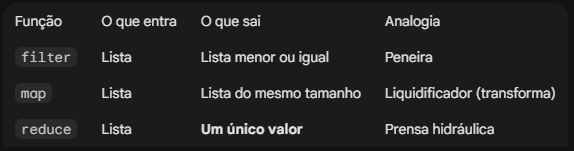

## Por que o reduce é menos usado que os outros?
O criador do Python, Guido van Rossum, não é muito fã do reduce. Ele acredita que, na maioria das vezes, um loop for ou funções nativas como sum(), max() e min() são muito mais fáceis de ler.

- Em vez de reduce para somar: use sum(lista).

- Em vez de reduce para o maior valor: use max(lista).

O reduce só brilha mesmo quando você tem uma lógica de acumulação muito específica e "fora da caixa".